<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/StockPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stock Price Prediction using Simple RNN

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [22]:
# Common libraries for file system operations, data handling, and numerical operations
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn for data scaling and evaluation metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow and Keras for building and training the neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

### 1. Library Imports

This section imports all necessary libraries for data manipulation, visualization, machine learning preprocessing, and building the Simple RNN model with TensorFlow/Keras.

In [2]:
dataset_path = "/content/drive/MyDrive/dataset/Stock_Price_Dataset"

csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))

print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

['/content/drive/MyDrive/dataset/Stock_Price_Dataset/X_train.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/y_train.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/X_test.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/y_test.csv']


,Volume,close_lag_1,close_lag_2,close_lag_3,rolling_mean_5,rolling_std_5
0,AAPL,NaN,NaN,NaN,NaN,NaN
1,237458000,23.887285,23.556961,23.554735,24.008324,0.527137
2,214798000,24.805082,23.887285,23.556961,24.127150,0.645421
3,198603200,24.831688,24.805082,23.887285,24.260167,0.560967
4,268367600,24.219820,24.831688,24.805082,24.435746,0.400192


In [23]:
dataset_path = "/content/drive/MyDrive/dataset/Stock_Price_Dataset"

# Get a list of all CSV files in the dataset directory
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))

print("Available CSV files:", csv_files)

# Load the first CSV file (assumed to be X_train.csv) into a DataFrame for feature analysis
df = pd.read_csv(csv_files[0])

# Display the head of the DataFrame to inspect its structure and data
df.head()

Available CSV files: ['/content/drive/MyDrive/dataset/Stock_Price_Dataset/X_train.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/y_train.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/X_test.csv', '/content/drive/MyDrive/dataset/Stock_Price_Dataset/y_test.csv']


,Volume,close_lag_1,close_lag_2,close_lag_3,rolling_mean_5,rolling_std_5
0,AAPL,NaN,NaN,NaN,NaN,NaN
1,237458000,23.887285,23.556961,23.554735,24.008324,0.527137
2,214798000,24.805082,23.887285,23.556961,24.127150,0.645421
3,198603200,24.831688,24.805082,23.887285,24.260167,0.560967
4,268367600,24.219820,24.831688,24.805082,24.435746,0.400192


### 2. Data Loading and Initial Inspection

Here, we define the path to our dataset and load the main training data (`X_train.csv`) into a pandas DataFrame. We then display the first few rows to understand its structure and content.

In [3]:
print(df.columns)

print(df.info())

print(df.describe())

Index(['Volume', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'rolling_mean_5',
       'rolling_std_5'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809 entries, 0 to 1808
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Volume          1809 non-null   object 
 1   close_lag_1     1808 non-null   float64
 2   close_lag_2     1808 non-null   float64
 3   close_lag_3     1808 non-null   float64
 4   rolling_mean_5  1808 non-null   float64
 5   rolling_std_5   1808 non-null   float64
dtypes: float64(5), object(1)
memory usage: 84.9+ KB
None
       close_lag_1  close_lag_2  close_lag_3  rolling_mean_5  rolling_std_5
count  1808.000000  1808.000000  1808.000000     1808.000000    1808.000000
mean     61.570774    61.499874    61.426917       61.497752       0.942760
std      43.094538    43.051528    43.003951       43.028917       1.020778
min      20.604076    20.604076    20.604076 

In [24]:
# Print column names to verify loaded features
print("DataFrame Columns:", df.columns)

# Print concise summary of the DataFrame including data types and non-null values
print("\nDataFrame Info:")
print(df.info())

# Generate descriptive statistics for numerical columns
print("\nDataFrame Description:")
print(df.describe())

DataFrame Columns: Index(['Volume', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'rolling_mean_5',
       'rolling_std_5'],
      dtype='object')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809 entries, 0 to 1808
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Volume          1809 non-null   object 
 1   close_lag_1     1808 non-null   float64
 2   close_lag_2     1808 non-null   float64
 3   close_lag_3     1808 non-null   float64
 4   rolling_mean_5  1808 non-null   float64
 5   rolling_std_5   1808 non-null   float64
dtypes: float64(5), object(1)
memory usage: 84.9+ KB
None

DataFrame Description:
       close_lag_1  close_lag_2  close_lag_3  rolling_mean_5  rolling_std_5
count  1808.000000  1808.000000  1808.000000     1808.000000    1808.000000
mean     61.570774    61.499874    61.426917       61.497752       0.942760
std      43.094538    43.051528    43.003951       43.028917 

### 3. Data Overview

This section provides a summary of the loaded DataFrame, including column names, data types, non-null values, and descriptive statistics, which helps in understanding data quality and distribution.

In [4]:
df = df.dropna()

In [25]:
# Drop rows with any missing values to ensure clean data for further processing
df = df.dropna()

### 4. Handling Missing Values

Missing values can cause issues in model training. This step removes any rows containing `NaN` values from the DataFrame.

In [6]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

In [26]:
if 'Date' in df.columns:
    # Convert the 'Date' column to datetime objects
    df['Date'] = pd.to_datetime(df['Date'])
    # Sort the DataFrame by 'Date' in ascending order
    df = df.sort_values('Date')

### 5. Date Column Processing

If a 'Date' column exists, it is converted to datetime objects and the DataFrame is sorted by date to ensure proper temporal order for time series analysis.

In [9]:
prices = pd.read_csv(csv_files[1]).values

In [27]:
# Load the actual stock prices (target variable) from the 'y_train.csv' file
# The original 'df' contains features, 'prices' contains the 'Adj Close' values.
prices = pd.read_csv(csv_files[1]).values

### 6. Extracting Target Variable (Prices)

We load the target variable (stock prices) from `y_train.csv` (the second CSV file) for our model. This is the value the model will try to predict.

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(prices)

In [28]:
# Initialize MinMaxScaler to scale data to a range of (0, 1)
scaler = MinMaxScaler(feature_range=(0,1))

# Apply the scaler to the prices data
scaled_data = scaler.fit_transform(prices)

### 7. Data Scaling

Neural networks often perform better when input data is scaled. `MinMaxScaler` transforms the prices to a range between 0 and 1.

In [11]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1748, 60, 1)
(1748, 1)


In [29]:
# Define the length of the time sequence (number of previous days to consider)
sequence_length = 60

# Initialize lists to store input sequences (X) and corresponding target values (y)
X = []
y = []

# Create sequences from the scaled data
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i]) # X is the sequence of 'sequence_length' prices
    y.append(scaled_data[i])                      # y is the next price after the sequence

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

# Print the shapes of the created arrays to verify dimensions
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (1748, 60, 1)
Shape of y (target): (1748, 1)


### 8. Creating Time Series Sequences

For RNNs, data needs to be structured into sequences where each `X` entry is a sequence of past prices, and `y` is the next price to predict. `sequence_length` defines how many past timesteps are used to predict the future.

In [12]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [30]:
# Define the split point for training data (80% of total data)
train_size = int(len(X)*0.8)

# Split the input sequences (X) into training and testing sets
X_train = X[:train_size]
X_test = X[train_size:]

# Split the target values (y) into training and testing sets
y_train = y[:train_size]
y_test = y[train_size:]

### 9. Splitting Data into Training and Testing Sets

The data is split into training (80%) and testing (20%) sets. It's crucial for time series to maintain chronological order, so we split sequentially rather than randomly.

In [13]:
model = Sequential()

model.add(SimpleRNN(
    units=64,
    activation='tanh',
    return_sequences=True,
    input_shape=(X_train.shape[1],1)
))

model.add(Dropout(0.2))

model.add(SimpleRNN(
    units=32,
    activation='tanh'
))

model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Initialize a sequential model
model = Sequential()

# Add the first SimpleRNN layer
model.add(SimpleRNN(
    units=64,                      # Number of RNN units (neurons)
    activation='tanh',             # Activation function for RNN cells
    return_sequences=True,         # Return full sequence of outputs for the next RNN layer
    input_shape=(X_train.shape[1],1) # Input shape: (sequence_length, number_of_features)
))

# Add Dropout layer for regularization to prevent overfitting
model.add(Dropout(0.2)) # Drop 20% of the neurons during training

# Add a second SimpleRNN layer
model.add(SimpleRNN(
    units=32,                      # Number of RNN units
    activation='tanh'              # Activation function
    # return_sequences=False by default for the last RNN layer
))

# Add another Dropout layer
model.add(Dropout(0.2))

# Add a Dense output layer with 1 unit for predicting a single stock price
model.add(Dense(1))

# Print a summary of the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Building the Simple RNN Model

This section defines the architecture of the Simple Recurrent Neural Network. It consists of two SimpleRNN layers with Dropout for regularization, followed by a Dense output layer.

In [14]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [32]:
# Compile the model
model.compile(
    optimizer='adam',         # Adam optimizer for efficient gradient descent
    loss='mean_squared_error' # Mean Squared Error as the loss function for regression
)

### 11. Compiling the Model

Before training, the model needs to be compiled. We specify the optimizer (Adam) and the loss function (Mean Squared Error) for regression tasks.

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0504 - val_loss: 0.0065
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0081 - val_loss: 0.0179
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0061 - val_loss: 0.0074
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0041 - val_loss: 0.0077
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0033 - val_loss: 0.0054
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 0.0053
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0016 - val_loss: 6.0682e-04
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0017 - val_loss: 5.6796e-04
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0018 - val_loss: 7.5083e-04
Epoch 12/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

In [33]:
# Train the model
history = model.fit(
    X_train,                     # Training input sequences
    y_train,                     # Training target values
    epochs=30,                   # Number of times to iterate over the entire dataset
    batch_size=32,               # Number of samples per gradient update
    validation_data=(X_test,y_test) # Data to evaluate the loss and any model metrics at the end of each epoch
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0604 - val_loss: 0.0026
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0090 - val_loss: 0.0240
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0060 - val_loss: 0.0117
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0049 - val_loss: 0.0140
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0036 - val_loss: 0.0082
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0029 - val_loss: 0.0041
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0030 - val_loss: 0.0038
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0023 - val_loss: 0.0043
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0021 - val_loss: 0.0094
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 0.0085
Epoch 12/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0

### 12. Training the Model

The model is trained using the `fit` method on the training data. We specify the number of epochs, batch size, and validation data to monitor performance during training.

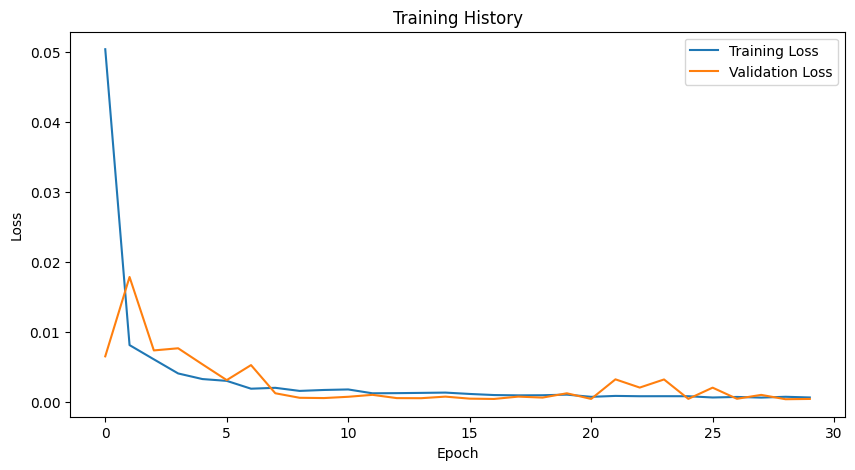

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")

plt.show()

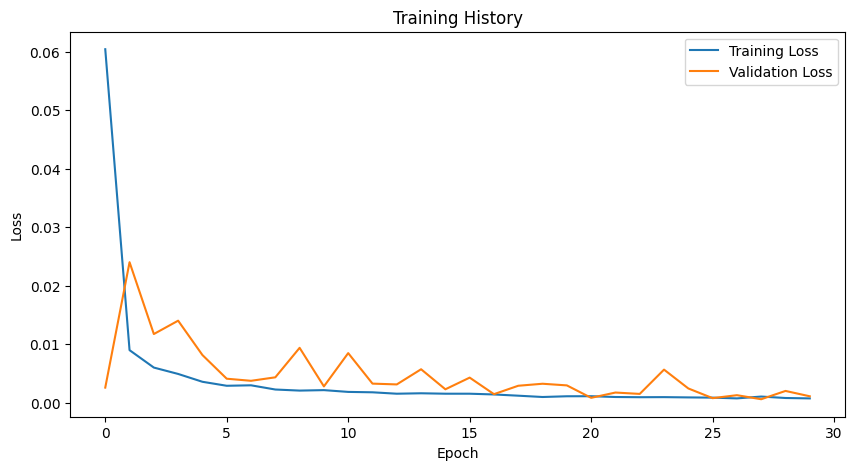

In [34]:
# Create a figure for plotting
plt.figure(figsize=(10,5))

# Plot training loss
plt.plot(history.history['loss'],label='Training Loss')
# Plot validation loss
plt.plot(history.history['val_loss'],label='Validation Loss')

# Add a legend, labels, and title
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")

# Display the plot
plt.show()

### 13. Visualizing Training History

This plot shows the training loss and validation loss over epochs, which helps in identifying overfitting or underfitting.

In [17]:
predictions = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step


In [35]:
# Use the trained model to make predictions on the test set
predictions = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


### 14. Making Predictions

After training, the model predicts stock prices on the unseen test data.

In [18]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

In [36]:
# Inverse transform the predictions to get actual price values
predictions = scaler.inverse_transform(predictions)

# Inverse transform the actual test values to get actual price values
actual = scaler.inverse_transform(y_test)

### 15. Inverse Scaling Predictions and Actual Values

Since the data was scaled before training, the predictions and actual values need to be inverse-transformed back to their original scale for meaningful interpretation.

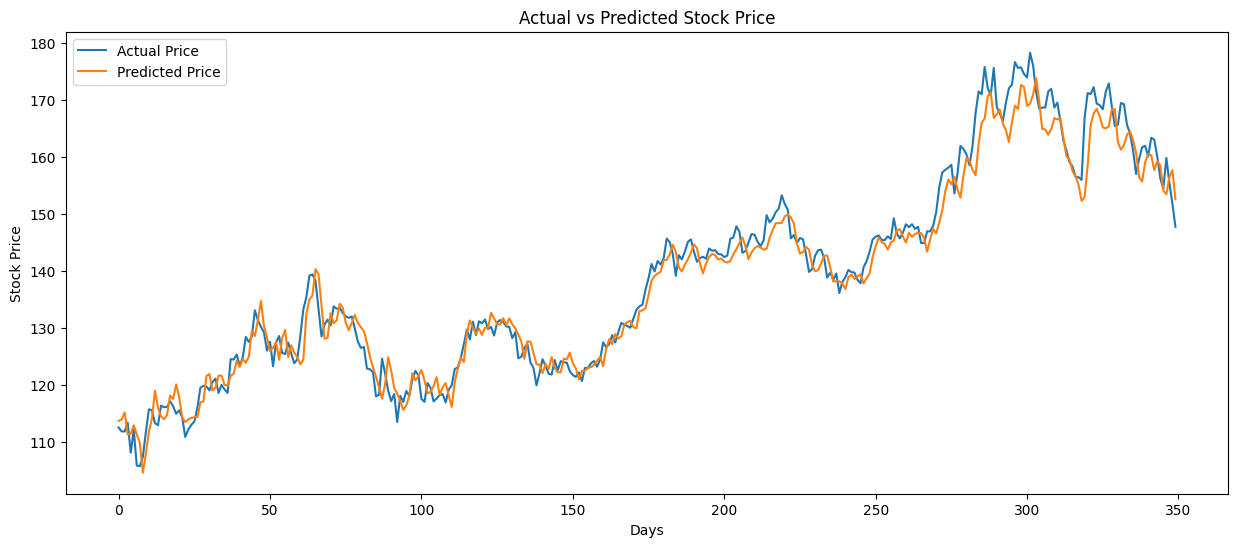

In [19]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual Price')
plt.plot(predictions,label='Predicted Price')

plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.title("Actual vs Predicted Stock Price")

plt.legend()

plt.show()

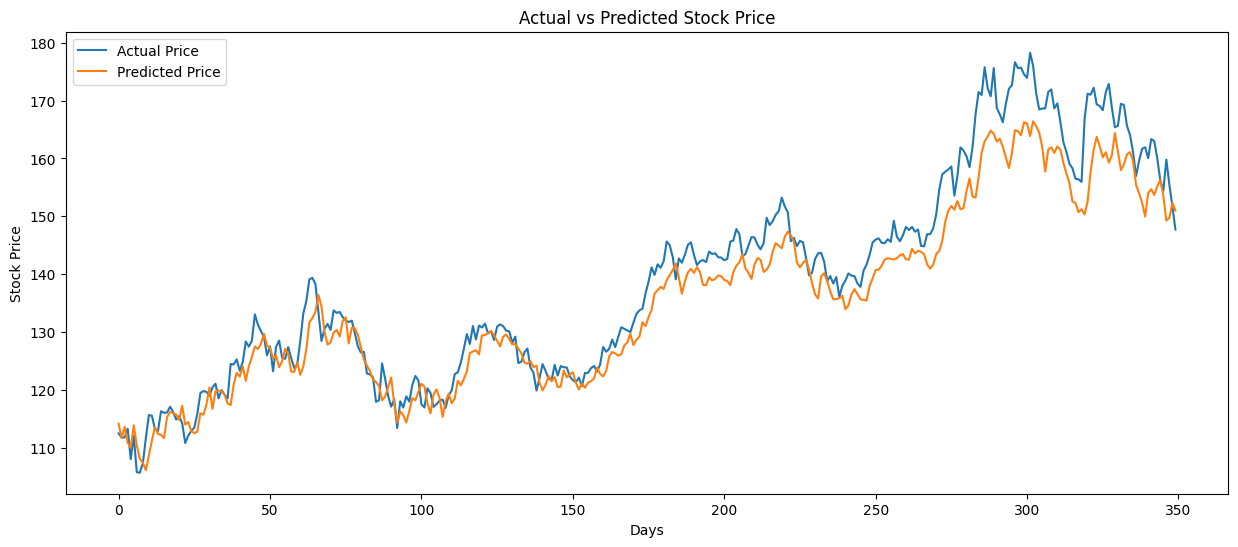

In [37]:
# Create a figure for plotting
plt.figure(figsize=(15,6))

# Plot the actual stock prices
plt.plot(actual,label='Actual Price')
# Plot the predicted stock prices
plt.plot(predictions,label='Predicted Price')

# Add labels and title
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Price")

# Add a legend and display the plot
plt.legend()
plt.show()

### 16. Visualizing Actual vs. Predicted Prices

This plot compares the actual stock prices from the test set against the prices predicted by the RNN model.

In [20]:
last_60 = scaled_data[-60:]

last_60 = last_60.reshape((1,60,1))

next_price = model.predict(last_60)

next_price = scaler.inverse_transform(next_price)

print("Predicted Next Day Price =",next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Next Day Price = 148.04395


In [38]:
# Get the last 'sequence_length' data points from the scaled data
last_60 = scaled_data[-60:]

# Reshape the data to match the input shape required by the RNN model (1 sample, sequence_length timesteps, 1 feature)
last_60 = last_60.reshape((1,60,1))

# Predict the next price using the trained model
next_price = model.predict(last_60)

# Inverse transform the predicted price to its original scale
next_price = scaler.inverse_transform(next_price)

# Print the predicted next day's stock price
print("Predicted Next Day Price =",next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Next Day Price = 145.38908


### 17. Predicting the Next Day's Price

This section demonstrates how to predict the stock price for the next day using the last `sequence_length` prices from the scaled data.

In [21]:
model.save("StockPrice_RNN_Model.h5")

In [39]:
# Save the trained Keras model to an HDF5 file
# Note: Keras recommends saving models in the native Keras format (.keras) for newer versions.
model.save("StockPrice_RNN_Model.h5")

### 18. Saving the Trained Model

The trained RNN model is saved to a file (`StockPrice_RNN_Model.h5`) for future use, so it doesn't need to be retrained every time.